# Proppuesta 4
## Autor: Yasin Hanin Boukaddidi

In [ ]:
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found. Go to Runtime > Change runtime type and select GPU.')
else:
  print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


In [ ]:
import pandas as pd

df = pd.read_csv('tcga_simple_train.csv')
print(df.columns)

text_list = df['text'].to_list()
tags = list(sorted(set(df['t'].to_list())))
print(tags)

Index(['patient_id', 'text', 't'], dtype='object')
['T1', 'T2', 'T3', 'T4']


In [ ]:
label_to_int = {tag: i for i, tag in enumerate(tags)}
print(label_to_int)
labels = [label_to_int[tag] for tag in df['t'].to_list()]

{'T1': 0, 'T2': 1, 'T3': 2, 'T4': 3}


In [ ]:
import numpy as np
from tensorflow.keras.utils import to_categorical

# Convertir etiquetas a categorical (One-Hot Encoding)
# labels ya contiene los enteros de 0 a 3
y_categorical = to_categorical(labels)
print(f'Forma de las etiquetas originales: {np.array(labels).shape}')
print(f'Forma de las etiquetas categóricas: {y_categorical.shape}')

Forma de las etiquetas originales: (5158,)
Forma de las etiquetas categóricas: (5158, 4)


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel

# Cambiando BioBERT por ClinicalBERT
model_name = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model     = AutoModel.from_pretrained(model_name)

# Verificar disponibilidad de GPU
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = model.to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CUDA available: True
Device: Tesla T4


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(28996, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [ ]:
import torch
from keras.preprocessing.sequence import pad_sequences

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

def prepare_vocabulary(corpus):
    word_to_int = {}
    int_to_vec = {}

    for texto in corpus:
        tokens_enc = tokenizer(texto, return_tensors="pt", truncation=True, max_length=128).to(device)
        tokens_texto = tokenizer.convert_ids_to_tokens(tokens_enc["input_ids"][0])

        with torch.no_grad():
            output = model(**tokens_enc)

        vectores = output.last_hidden_state[0]
        palabra_actual = ""
        vecs_acum = []

        for token, vec in zip(tokens_texto, vectores):
            if token in ["[CLS]", "[SEP]", "[PAD]"]:
                continue

            if token.startswith("##"):
                palabra_actual += token[2:]
                vecs_acum.append(vec)
            else:
                if palabra_actual and vecs_acum and palabra_actual not in word_to_int:
                    idx = len(word_to_int)
                    word_to_int[palabra_actual] = idx
                    int_to_vec[idx] = torch.stack(vecs_acum).mean(0).cpu()
                palabra_actual = token.lower().strip(".,;:- ")
                vecs_acum = [vec]

        if palabra_actual and vecs_acum and palabra_actual not in word_to_int:
            idx = len(word_to_int)
            word_to_int[palabra_actual] = idx
            int_to_vec[idx] = torch.stack(vecs_acum).mean(0).cpu()

    return word_to_int, int_to_vec


def prepare_sentences(corpus, word_to_int, maxlen):
    encoded_sentences = []

    for sentence in corpus:
        tokens = tokenizer.tokenize(sentence)
        encoded = []
        palabra_actual = ""

        for token in tokens:
            if token in ["[CLS]", "[SEP]", "[PAD]"]:
                continue
            if token.startswith("##"):
                palabra_actual += token[2:]
            else:
                if palabra_actual:
                    encoded.append(word_to_int.get(palabra_actual, 0))
                palabra_actual = token.lower().strip(".,;:- ")

        if palabra_actual:
            encoded.append(word_to_int.get(palabra_actual, 0))

        encoded_sentences.append(encoded)

    prepared = pad_sequences(encoded_sentences, maxlen=maxlen, padding='post', truncating='post')
    print("Sentencias preparadas!")
    return prepared

Longitud máxima real: 3862
Longitud (mediana) seleccionada como maxlen: 430


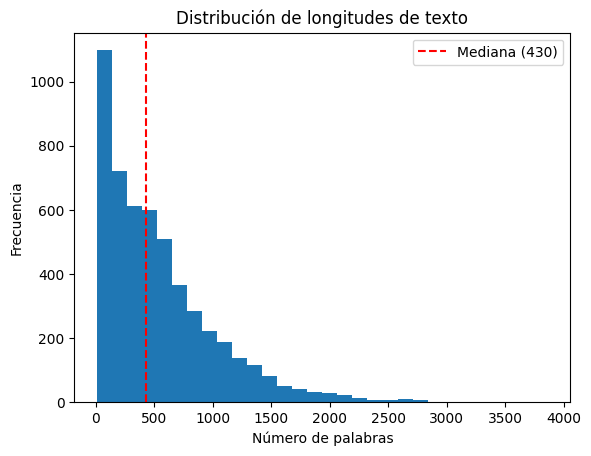

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculamos la longitud de cada texto (número de palabras)
sentence_lengths = [len(text.split()) for text in df['text']]

# Usamos la mediana como longitud máxima para el padding
maxlen = int(np.median(sentence_lengths))

print(f'Longitud máxima real: {max(sentence_lengths)}')
print(f'Longitud (mediana) seleccionada como maxlen: {maxlen}')

# Visualizamos la distribución
plt.hist(sentence_lengths, bins=30)
plt.axvline(maxlen, color='r', linestyle='--', label=f'Mediana ({maxlen})')
plt.title('Distribución de longitudes de texto')
plt.xlabel('Número de palabras')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

In [ ]:
word_to_int, int_to_vec = prepare_vocabulary(df['text'].to_list())


In [ ]:
prepared_sentences = prepare_sentences(df['text'].to_list(), word_to_int, maxlen)
print(f'Forma de la matriz: {prepared_sentences.shape}')
print("maxlen", maxlen)

Sentencias preparadas!
Forma de la matriz: (5158, 430)
maxlen 430


In [ ]:
vocab = list(word_to_int.keys())
vocab_size = len(vocab)

matrix = []
for i, vec in int_to_vec.items():
    matrix.append(vec.numpy())

embedding_matrix = np.array(matrix)
vector_size = embedding_matrix.shape[1]

print(f'Forma de la matriz de embeddings: {embedding_matrix.shape}')

Forma de la matriz de embeddings: (10185, 768)


In [ ]:
from keras.models import Sequential
from keras.layers import GlobalAveragePooling1D, Dense, Embedding, Input, Dropout
import keras
import numpy as np

# Métrica F1 nativa
macro_f1_native = keras.metrics.F1Score(average='macro', name='macro_f1')


model = Sequential()
model.add(Input(shape=(int(maxlen),)))

# Permitimos que los embeddings se entrenen (Fine-tuning) para adaptarse al dominio médico,
# aunque opr defecto es mejor q no al tener pocos datos
model.add(Embedding(vocab_size, vector_size, weights=[embedding_matrix], trainable=True))

# Sustituimos Flatten por GlobalAveragePooling1D para reducir parámetros y evitar sobreajuste
model.add(GlobalAveragePooling1D())

model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))  # añadir esto
model.add(Dropout(0.3))

model.add(Dense(len(tags), activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', macro_f1_native]
)

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 430, 768)       │     7,822,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_6      │ (None, 768)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │        24,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,846,820 (29.93 MB)

 Trainable params: 7,846,820 (29.93 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical

# 1. Preparar etiquetas
le = LabelEncoder()
y_encoded = le.fit_transform(df['t'])
y_categorical = to_categorical(y_encoded)

# 2. Convertir a arrays
X = np.array(prepared_sentences)
y = y_categorical

# 3. Dividir: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
from keras.callbacks import EarlyStopping

# Configuramos EarlyStopping para evitar el sobreajuste
# monitor='val_loss': vigila la pérdida en validación
# patience=3: si no mejora en 3 épocas, se detiene
# restore_best_weights=True: recupera los pesos de la mejor época
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

# Evaluar nuevamente con los mejores pesos
results = model.evaluate(X_test, y_test)
print(f'\nTest Loss: {results[0]}')
print(f'Test Accuracy: {results[1]}')
print(f'Test Macro F1: {results[2]}')

Epoch 1/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.3227 - loss: 1.3525 - macro_f1: 0.2453 - val_accuracy: 0.3669 - val_loss: 1.2796 - val_macro_f1: 0.1411
Epoch 2/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3399 - loss: 1.2965 - macro_f1: 0.2575 - val_accuracy: 0.4186 - val_loss: 1.2511 - val_macro_f1: 0.2611
Epoch 3/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3814 - loss: 1.2704 - macro_f1: 0.2961 - val_accuracy: 0.4897 - val_loss: 1.2028 - val_macro_f1: 0.3747
Epoch 4/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4283 - loss: 1.2188 - macro_f1: 0.3399 - val_accuracy: 0.4845 - val_loss: 1.1394 - val_macro_f1: 0.3798
Epoch 5/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4626 - loss: 1.1676 - macro_f1: 0.3660 - val_accuracy: 0.4922 - val_loss: 1.1210 - val_macro_f1: 0.3854
Epoch 6/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4773 - loss: 1.1450 - macro_f1: 0.3829 - val_accuracy: 0.5065 - val_loss: 1.0830 - 

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32
)

# Evaluar en el conjunto de test
results = model.evaluate(X_test, y_test)
print(f'Test Loss: {results[0]}')
print(f'Test Accuracy: {results[1]}')
print(f'Test Macro F1: {results[2]}')

Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.3440 - loss: 1.3463 - macro_f1: 0.2728 - val_accuracy: 0.4199 - val_loss: 1.2268 - val_macro_f1: 0.3008
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4252 - loss: 1.2381 - macro_f1: 0.3390 - val_accuracy: 0.4961 - val_loss: 1.1682 - val_macro_f1: 0.3784
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4756 - loss: 1.1775 - macro_f1: 0.3820 - val_accuracy: 0.5026 - val_loss: 1.1698 - val_macro_f1: 0.3831
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5169 - loss: 1.1184 - macro_f1: 0.4230 - val_accuracy: 0.4961 - val_loss: 1.0852 - val_macro_f1: 0.3782
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5388 - loss: 1.0714 - macro_f1: 0.4488 - val_accuracy: 0.4806 - val_loss: 1.0879 - val_macro_f1: 0.3805
Epoch 6/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5568 - loss: 1.0338 - macro_f1: 0.4782 - val_accuracy: 0.5465 - val_loss: 1.0311 - 

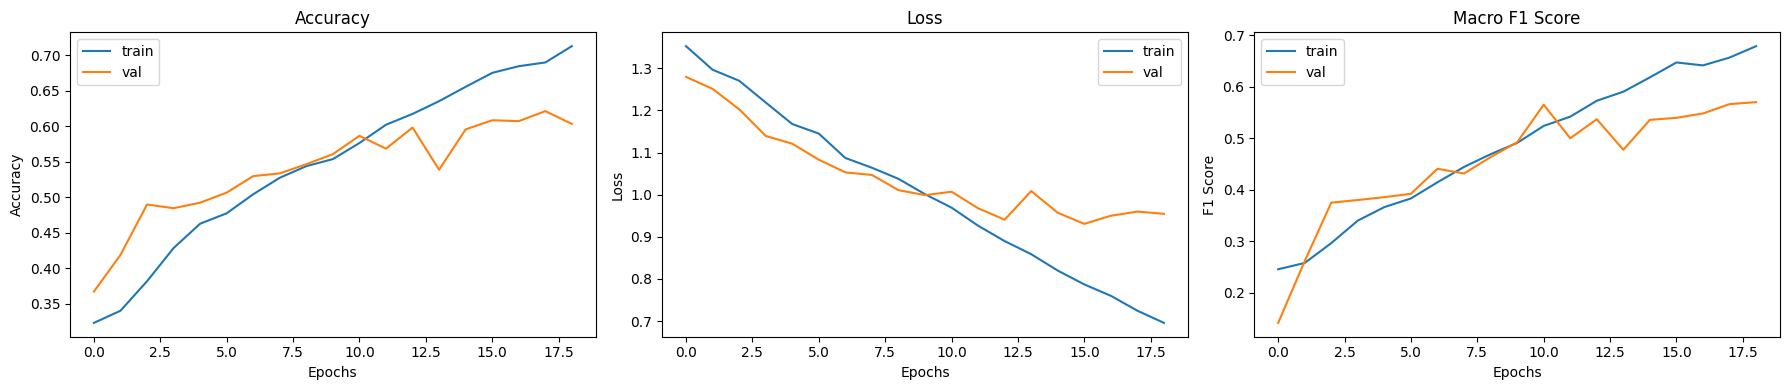

In [ ]:
import matplotlib.pyplot as plt

# Visualizar curvas de entrenamiento (Accuracy, Loss y F1)
plt.figure(figsize=(18, 4))

# Subplot para Accuracy
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Subplot para Loss
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Subplot para Macro F1
plt.subplot(1, 3, 3)
plt.plot(history.history['macro_f1'], label='train')
plt.plot(history.history['val_macro_f1'], label='val')
plt.title('Macro F1 Score')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.legend()

plt.tight_layout()
plt.show()

# Con BiLSTM

In [ ]:
from keras.models import Sequential
from keras.layers import GlobalAveragePooling1D, Dense, Embedding, Input, Dropout
from keras.layers import Bidirectional, LSTM
import keras
import numpy as np

# Métrica F1 nativa
macro_f1_native = keras.metrics.F1Score(average='macro', name='macro_f1')


model = Sequential()
model.add(Input(shape=(int(maxlen),)))

# Permitimos que los embeddings se entrenen (Fine-tuning) para adaptarse al dominio médico,
# aunque opr defecto es mejor q no al tener pocos datos
model.add(Embedding(vocab_size, vector_size, weights=[embedding_matrix], trainable=True))

# Sustituimos Flatten por GlobalAveragePooling1D para reducir parámetros y evitar sobreajuste
model.add(Bidirectional(LSTM(32, return_sequences=False)))

model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))  # añadir esto
model.add(Dropout(0.3))

model.add(Dense(len(tags), activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', macro_f1_native]
)

model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ (None, 430, 768)       │     7,822,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 64)             │       205,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,029,348 (30.63 MB)

 Trainable params: 8,029,348 (30.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras.callbacks import EarlyStopping

# Configuramos EarlyStopping para evitar el sobreajuste
# monitor='val_loss': vigila la pérdida en validación
# patience=3: si no mejora en 3 épocas, se detiene
# restore_best_weights=True: recupera los pesos de la mejor época
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

# Evaluar nuevamente con los mejores pesos
results = model.evaluate(X_test, y_test)
print(f'\nTest Loss: {results[0]}')
print(f'Test Accuracy: {results[1]}')
print(f'Test Macro F1: {results[2]}')

Epoch 1/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - accuracy: 0.3144 - loss: 1.3394 - macro_f1: 0.2437 - val_accuracy: 0.3695 - val_loss: 1.2815 - val_macro_f1: 0.2595
Epoch 2/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.3676 - loss: 1.2796 - macro_f1: 0.2899 - val_accuracy: 0.3708 - val_loss: 1.2501 - val_macro_f1: 0.2850
Epoch 3/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.4504 - loss: 1.1997 - macro_f1: 0.3616 - val_accuracy: 0.4638 - val_loss: 1.1533 - val_macro_f1: 0.3645
Epoch 4/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.5429 - loss: 1.0674 - macro_f1: 0.4387 - val_accuracy: 0.4755 - val_loss: 1.1098 - val_macro_f1: 0.3673
Epoch 5/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.6078 - loss: 0.9428 - macro_f1: 0.5213 - val_accuracy: 0.5271 - val_loss: 1.0800 - val_macro_f1: 0.4442
Epoch 6/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.6983 - loss: 0.7774 - macro_f1: 0.6383 - val_accuracy: 0.5491 - val_loss: 1.1

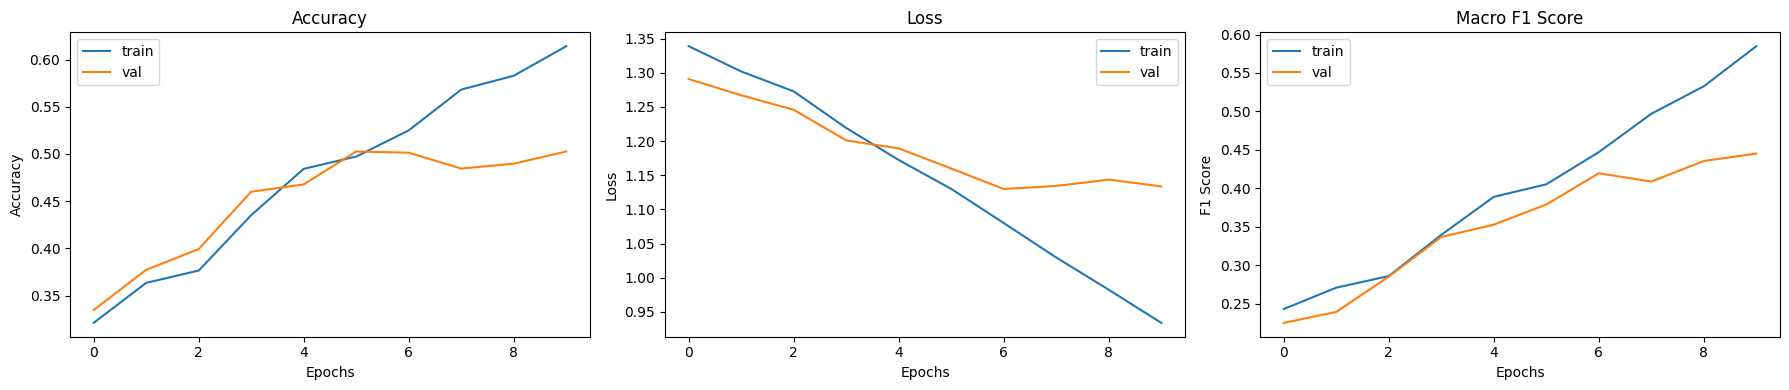

In [ ]:
import matplotlib.pyplot as plt

# Visualizar curvas de entrenamiento (Accuracy, Loss y F1)
plt.figure(figsize=(18, 4))

# Subplot para Accuracy
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Subplot para Loss
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Subplot para Macro F1
plt.subplot(1, 3, 3)
plt.plot(history.history['macro_f1'], label='train')
plt.plot(history.history['val_macro_f1'], label='val')
plt.title('Macro F1 Score')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.legend()

plt.tight_layout()
plt.show()